# Store Sales Forecasting with a Small HuggingFace Time Series Transformer

End-to-end pipeline: load the Favorita retail dataset, engineer a daily
per-store sales panel, train a compact `TimeSeriesTransformerForPrediction`
model (fits comfortably on a 4GB GPU), backtest it, and forecast the next
14 days of sales for every store. All figures and tables produced here are
also saved to `outputs/figures` and `outputs/tables` for use in the README.

# 1. Setup

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src import config
from src import data_preprocessing
from src.dataset import build_series, SalesWindowDataset
from src.model import build_model, count_parameters
from src.plotting import apply_theme, style_axes, PALETTE, GREEN_PRIMARY, TEAL, AMBER, RED, GREEN_DARK
from src.train import train_model, get_device
from src.evaluate import backtest
from src.predict import load_model, forecast_for_store, forecast_series
from src.metrics import compute_all_metrics

apply_theme()
pd.set_option("display.max_columns", 50)

device = get_device()
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA RTX A2000 Laptop GPU
GPU memory: 4.0 GB


# 2. Load Raw Data

In [2]:
train_raw = pd.read_csv(config.DATA_RAW_DIR / "train.csv", parse_dates=["date"])
stores = pd.read_csv(config.DATA_RAW_DIR / "stores.csv")
oil = pd.read_csv(config.DATA_RAW_DIR / "oil.csv", parse_dates=["date"])
transactions = pd.read_csv(config.DATA_RAW_DIR / "transactions.csv", parse_dates=["date"])
holidays = pd.read_csv(config.DATA_RAW_DIR / "holidays_events.csv", parse_dates=["date"])

print("train:", train_raw.shape)
print("stores:", stores.shape)
print("date range:", train_raw["date"].min().date(), "to", train_raw["date"].max().date())
train_raw.head()

train: (3000888, 6)
stores: (54, 5)
date range: 2013-01-01 to 2017-08-15


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


# 3. Exploratory Data Analysis

A quick look at overall demand, seasonality, store composition and the
relationship between sales and the other available signals (promotions,
oil price, holidays) before any modeling.

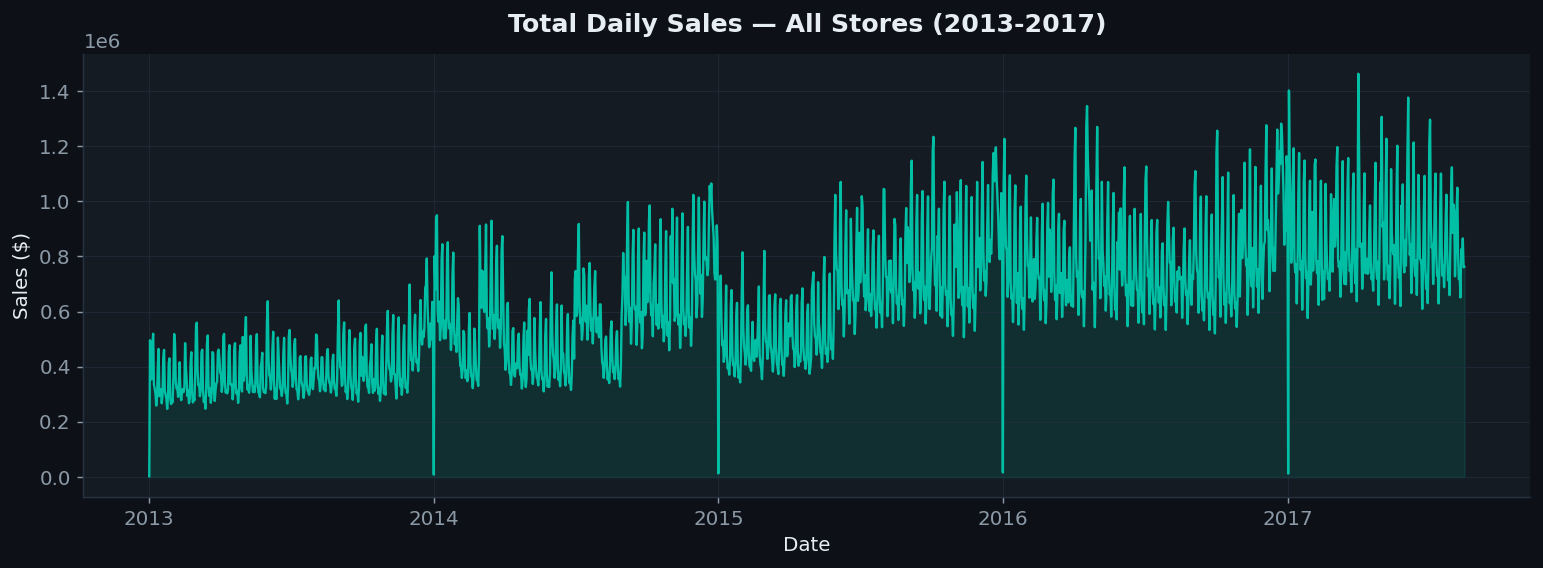

In [3]:
daily_total = train_raw.groupby("date")["sales"].sum()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(daily_total.index, daily_total.values, color=TEAL, linewidth=1.3)
ax.fill_between(daily_total.index, daily_total.values, color=TEAL, alpha=0.12)
style_axes(ax, title="Total Daily Sales — All Stores (2013-2017)", xlabel="Date", ylabel="Sales ($)")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "01_total_daily_sales.png")
plt.show()

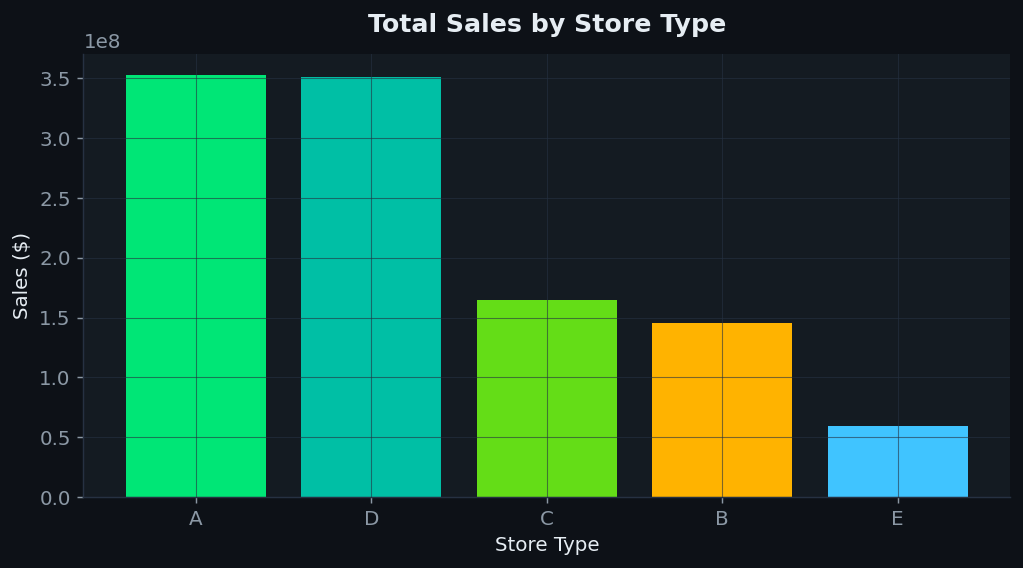

In [4]:
store_type_sales = train_raw.merge(stores, on="store_nbr").groupby("type")["sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(store_type_sales.index, store_type_sales.values, color=PALETTE[:len(store_type_sales)])
style_axes(ax, title="Total Sales by Store Type", xlabel="Store Type", ylabel="Sales ($)")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "02_sales_by_store_type.png")
plt.show()

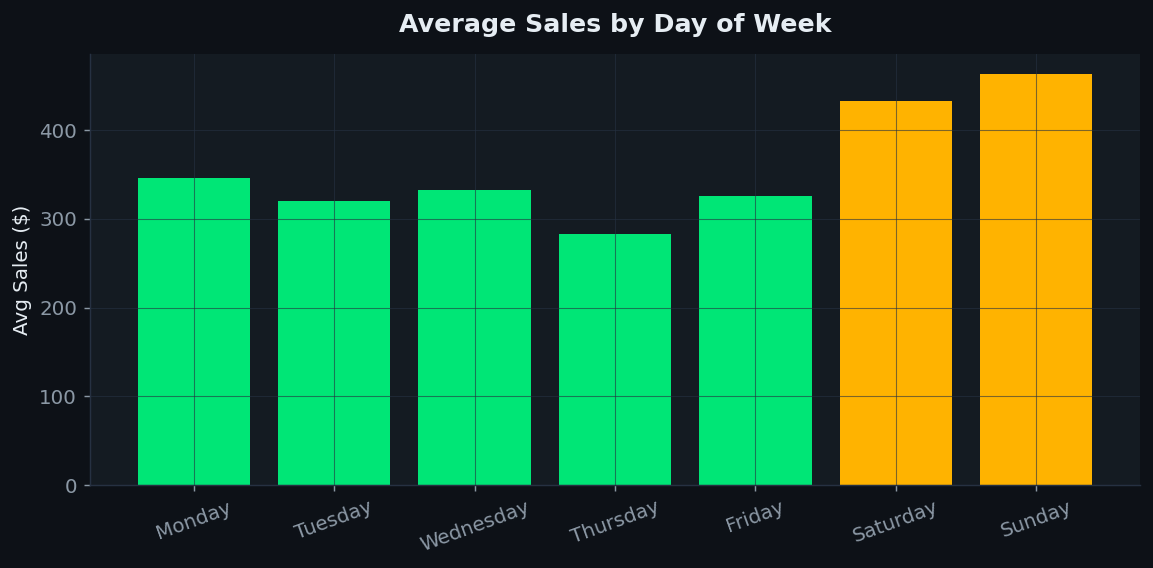

In [5]:
dow_sales = train_raw.copy()
dow_sales["dow"] = dow_sales["date"].dt.day_name()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_avg = dow_sales.groupby("dow")["sales"].mean().reindex(order)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [GREEN_PRIMARY if d not in ("Saturday", "Sunday") else AMBER for d in order]
ax.bar(dow_avg.index, dow_avg.values, color=colors)
style_axes(ax, title="Average Sales by Day of Week", xlabel="", ylabel="Avg Sales ($)")
plt.xticks(rotation=20)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "03_sales_by_day_of_week.png")
plt.show()

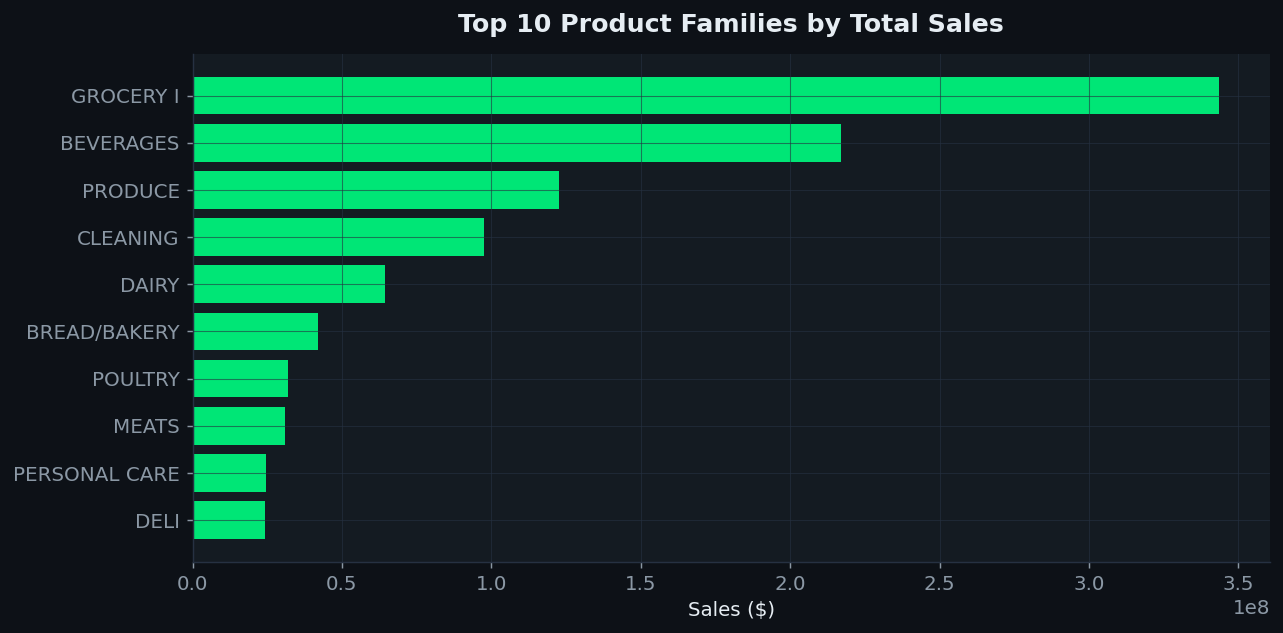

In [6]:
fam_sales = train_raw.groupby("family")["sales"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(fam_sales.index[::-1], fam_sales.values[::-1], color=GREEN_PRIMARY)
style_axes(ax, title="Top 10 Product Families by Total Sales", xlabel="Sales ($)", ylabel="")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "04_top_families.png")
plt.show()

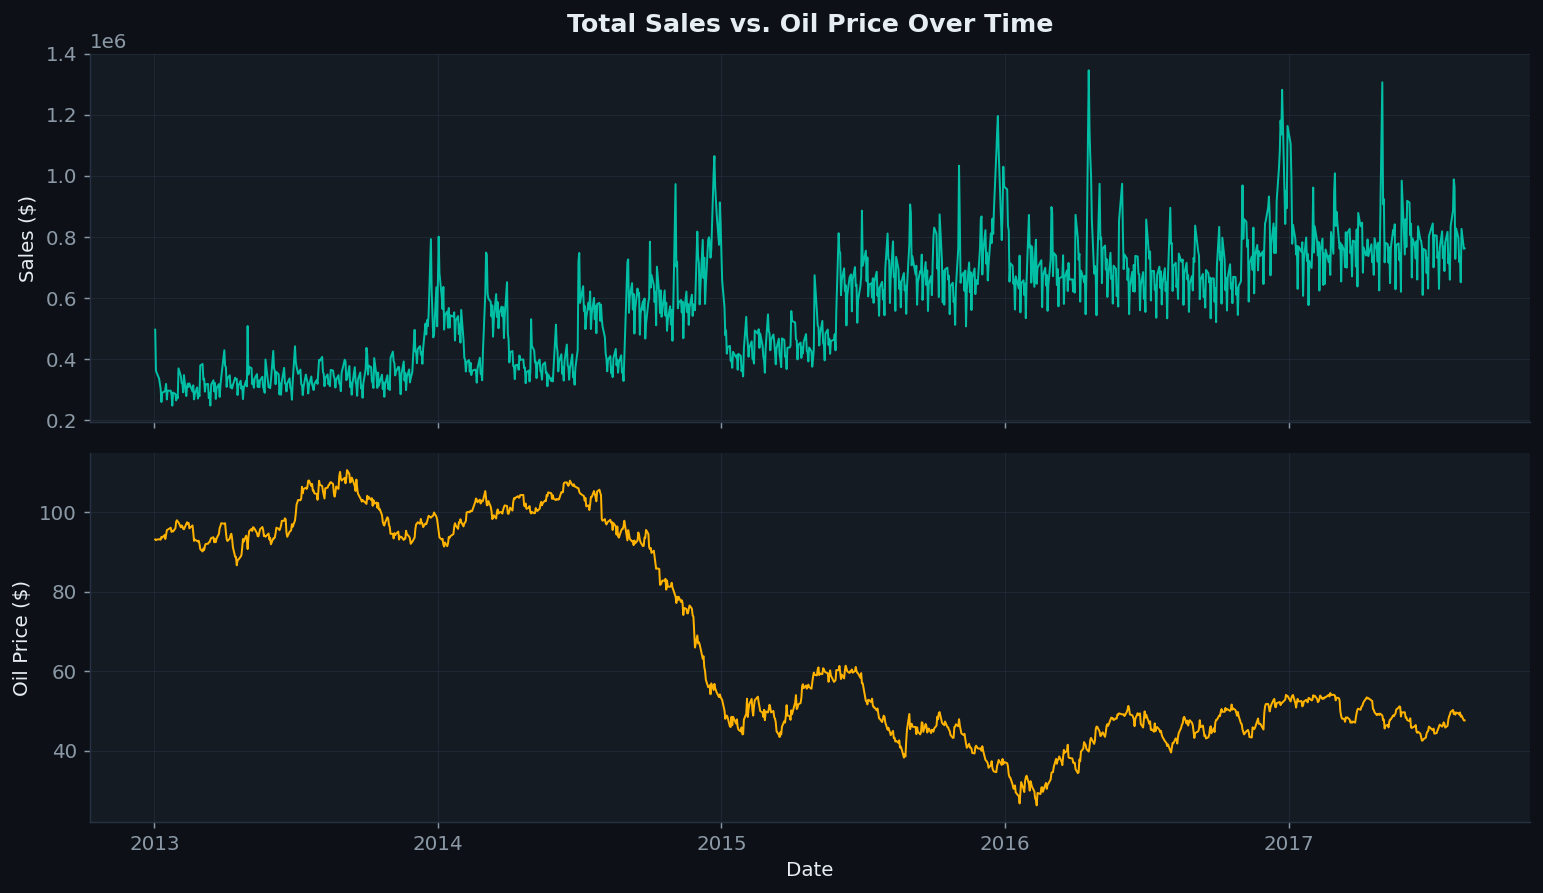

Correlation between total sales and oil price: -0.705


In [7]:
oil_clean = oil.dropna()
merged_oil = daily_total.reset_index().merge(oil_clean, on="date", how="inner")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax1.plot(merged_oil["date"], merged_oil["sales"], color=TEAL, linewidth=1.1)
style_axes(ax1, title="Total Sales vs. Oil Price Over Time", ylabel="Sales ($)")
ax2.plot(merged_oil["date"], merged_oil["dcoilwtico"], color=AMBER, linewidth=1.1)
style_axes(ax2, xlabel="Date", ylabel="Oil Price ($)")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "05_sales_vs_oil_price.png")
plt.show()

corr = merged_oil["sales"].corr(merged_oil["dcoilwtico"])
print(f"Correlation between total sales and oil price: {corr:.3f}")

# 4. Data Preprocessing

Aggregate raw transaction-level rows into one **daily total-sales series per
store** (54 series), and attach calendar, promotion, transaction-count,
oil-price and holiday covariates. This is the panel the model is trained on.

In [8]:
panel = data_preprocessing.build_daily_store_panel()
panel.to_parquet(config.DAILY_STORE_SALES_PATH, index=False)
print("Daily store panel shape:", panel.shape)
panel.head()

Daily store panel shape: (91152, 16)


,date,store_nbr,sales,onpromotion,dcoilwtico,transactions,is_holiday,city,state,type,cluster,day_of_week,day_of_month,day_of_year,month,is_weekend
0,2013-01-01,1,0.000000,0,93.14,0.0,1,Quito,Pichincha,D,13,1,1,1,1,0
1,2013-01-02,1,7417.147949,0,93.14,2111.0,0,Quito,Pichincha,D,13,2,2,2,1,0
2,2013-01-03,1,5873.244141,0,92.97,1833.0,0,Quito,Pichincha,D,13,3,3,3,1,0
3,2013-01-04,1,5919.878906,0,93.12,1863.0,0,Quito,Pichincha,D,13,4,4,4,1,0
4,2013-01-05,1,6318.785156,0,93.12,1509.0,1,Quito,Pichincha,D,13,5,5,5,1,1


In [9]:
summary_tbl = (
    panel.groupby("store_nbr")
    .agg(city=("city", "first"), state=("state", "first"), store_type=("type", "first"),
         avg_daily_sales=("sales", "mean"), total_sales=("sales", "sum"))
    .round(2)
    .sort_values("total_sales", ascending=False)
)
summary_tbl.to_csv(config.TABLES_DIR / "store_summary.csv")
summary_tbl.head(10)

,city,state,store_type,avg_daily_sales,total_sales
store_nbr,,,,,
44,Quito,Pichincha,A,36781.730469,62087552.0
45,Quito,Pichincha,A,32285.550781,54498012.0
47,Quito,Pichincha,A,30182.650391,50948312.0
3,Quito,Pichincha,D,29906.339844,50481908.0
49,Quito,Pichincha,A,25722.810547,43420100.0
46,Quito,Pichincha,A,24819.939453,41896064.0
48,Quito,Pichincha,A,21287.400391,35933132.0
51,Guayaquil,Guayas,A,19497.330078,32911490.0
8,Quito,Pichincha,D,18065.339844,30494284.0


# 5. Build the Windowed Dataset

Each training example is a sliding window: `context_length` days of history
(plus the extra lag history the model needs) used to predict the next
`prediction_length` days. A held-out tail of each series is reserved for
backtesting and is never seen during training.

In [10]:
series_list = build_series(panel)
train_ds = SalesWindowDataset(series_list, mode="train")
eval_ds = SalesWindowDataset(series_list, mode="eval")

print("Number of stores (series):", len(series_list))
print("Training windows:", len(train_ds))
print("Evaluation windows (1 per store):", len(eval_ds))

sample = train_ds[0]
for k, v in sample.items():
    print(f"{k:28s} {tuple(v.shape)}")

Number of stores (series): 54
Training windows: 84186
Evaluation windows (1 per store): 54
past_values                  (88,)
past_time_features           (88, 5)
past_observed_mask           (88,)
future_values                (14,)
future_time_features         (14, 5)
static_categorical_features  (1,)


# 6. Define the Model

A small `TimeSeriesTransformerForPrediction` (HuggingFace `transformers`):
`d_model=32`, 2 encoder + 2 decoder layers, 2 attention heads. It outputs a
full probability distribution (mean + samples) per forecasted day rather
than a single point estimate.

In [11]:
num_stores = int(panel["store_nbr"].max())
model = build_model(num_stores=num_stores)
print(f"Trainable parameters: {count_parameters(model):,}")
print(model.config)

Trainable parameters: 41,243
TimeSeriesTransformerConfig {
  "activation_dropout": 0.1,
  "activation_function": "gelu",
  "attention_dropout": 0.1,
  "cardinality": [
    55
  ],
  "context_length": 60,
  "d_model": 32,
  "decoder_attention_heads": 2,
  "decoder_ffn_dim": 32,
  "decoder_layerdrop": 0.1,
  "decoder_layers": 2,
  "distribution_output": "student_t",
  "dropout": 0.1,
  "embedding_dimension": [
    8
  ],
  "encoder_attention_heads": 2,
  "encoder_ffn_dim": 32,
  "encoder_layerdrop": 0.1,
  "encoder_layers": 2,
  "feature_size": 22,
  "init_std": 0.02,
  "input_size": 1,
  "is_encoder_decoder": true,
  "lags_sequence": [
    1,
    2,
    3,
    7,
    14,
    21,
    28
  ],
  "loss": "nll",
  "model_type": "time_series_transformer",
  "num_dynamic_real_features": 0,
  "num_parallel_samples": 100,
  "num_static_categorical_features": 1,
  "num_static_real_features": 0,
  "num_time_features": 5,
  "prediction_length": 14,
  "scaling": "mean",
  "transformers_version": "5.

# 7. Train the Model

In [12]:
model, history_df = train_model(panel=panel)
history_df.tail()

Device: cuda
Trainable parameters: 41,243
Training windows: 84,186


Epoch   1/30 | loss 6.7506 | 16.3s


Epoch   2/30 | loss 6.5103 | 16.6s


Epoch   3/30 | loss 6.4189 | 16.6s


Epoch   4/30 | loss 6.3628 | 15.6s


...

Epoch  29/30 | loss 6.0956 | 18.1s


Epoch  30/30 | loss 6.0997 | 18.3s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 131.36it/s]

,epoch,train_loss,lr,seconds
25,26,6.098115,0.000043,17.688386
26,27,6.099247,0.000024,18.399077
27,28,6.092323,0.000011,18.453750
28,29,6.095589,0.000003,18.079136
29,30,6.099668,0.000000,18.339345


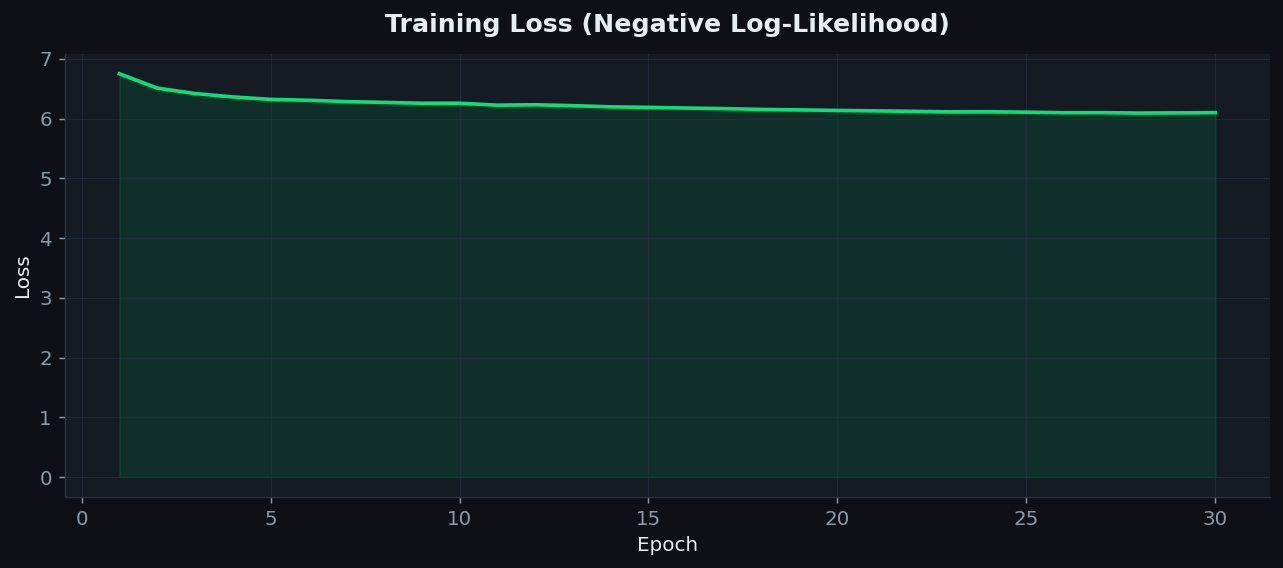

In [13]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(history_df["epoch"], history_df["train_loss"], color=GREEN_PRIMARY, linewidth=2)
ax.fill_between(history_df["epoch"], history_df["train_loss"], color=GREEN_PRIMARY, alpha=0.1)
style_axes(ax, title="Training Loss (Negative Log-Likelihood)", xlabel="Epoch", ylabel="Loss")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "06_training_loss.png")
plt.show()

# 8. Backtest Evaluation

Forecast the last 14 held-out days for every store and score the median
forecast (p50) against the actual observed sales using MAE, RMSE, sMAPE and
MASE (scaled against a naive weekly-seasonal baseline).

In [14]:
metrics_df, forecasts_df = backtest(panel, model=model, device=device)
metrics_df.to_csv(config.TABLES_DIR / "backtest_metrics_per_store.csv")
forecasts_df.to_csv(config.TABLES_DIR / "backtest_forecasts.csv", index=False)

overall = metrics_df.mean(numeric_only=True).round(3)
overall.to_csv(config.TABLES_DIR / "backtest_metrics_overall.csv")
print("Overall backtest metrics (averaged across all 54 stores):")
overall

Overall backtest metrics (averaged across all 54 stores):


MAE      1346.192
RMSE     1786.911
sMAPE      10.025
MASE        0.939
dtype: float64

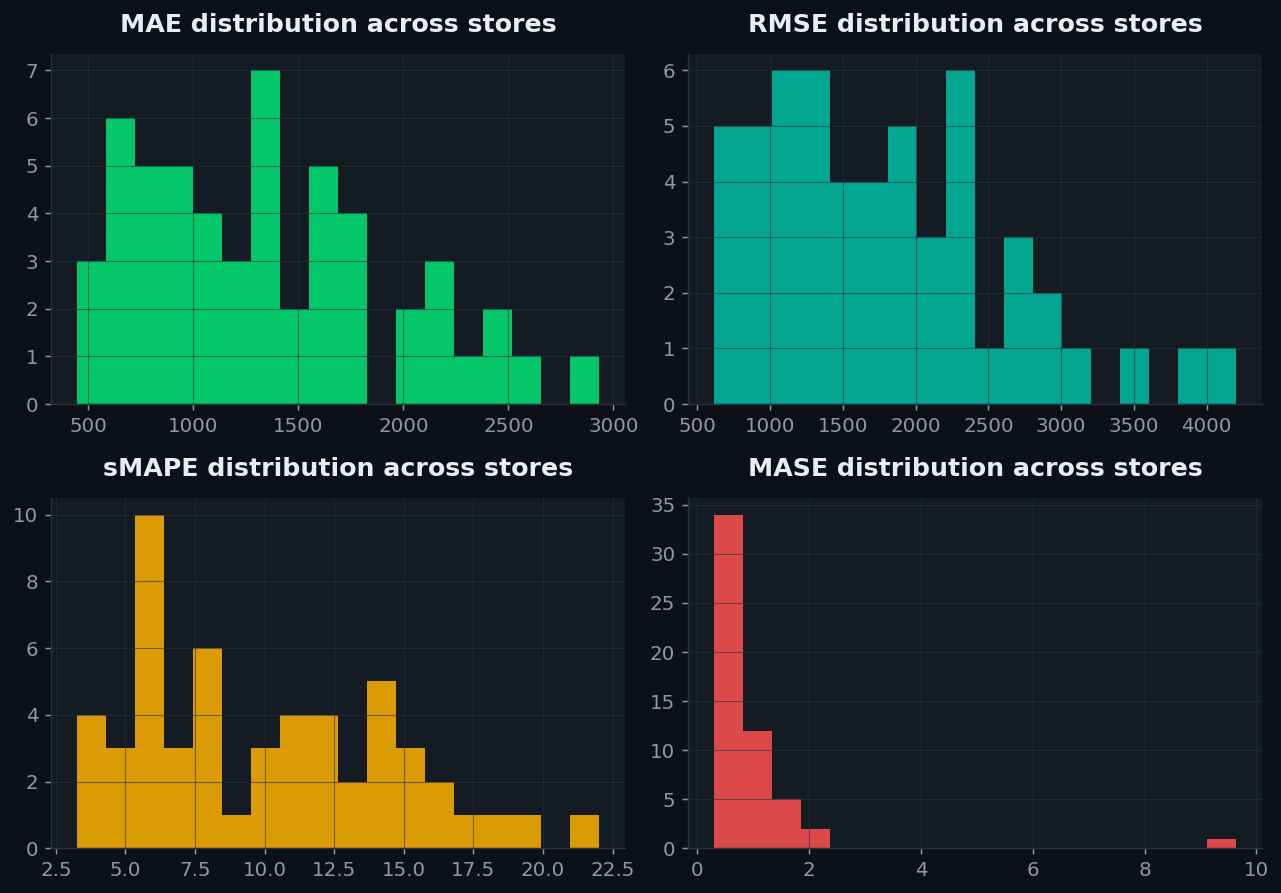

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
metric_names = ["MAE", "RMSE", "sMAPE", "MASE"]
colors = [GREEN_PRIMARY, TEAL, AMBER, RED]
for ax, m, c in zip(axes.flat, metric_names, colors):
    ax.hist(metrics_df[m], bins=18, color=c, alpha=0.85)
    style_axes(ax, title=f"{m} distribution across stores")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "07_backtest_metric_distributions.png")
plt.show()

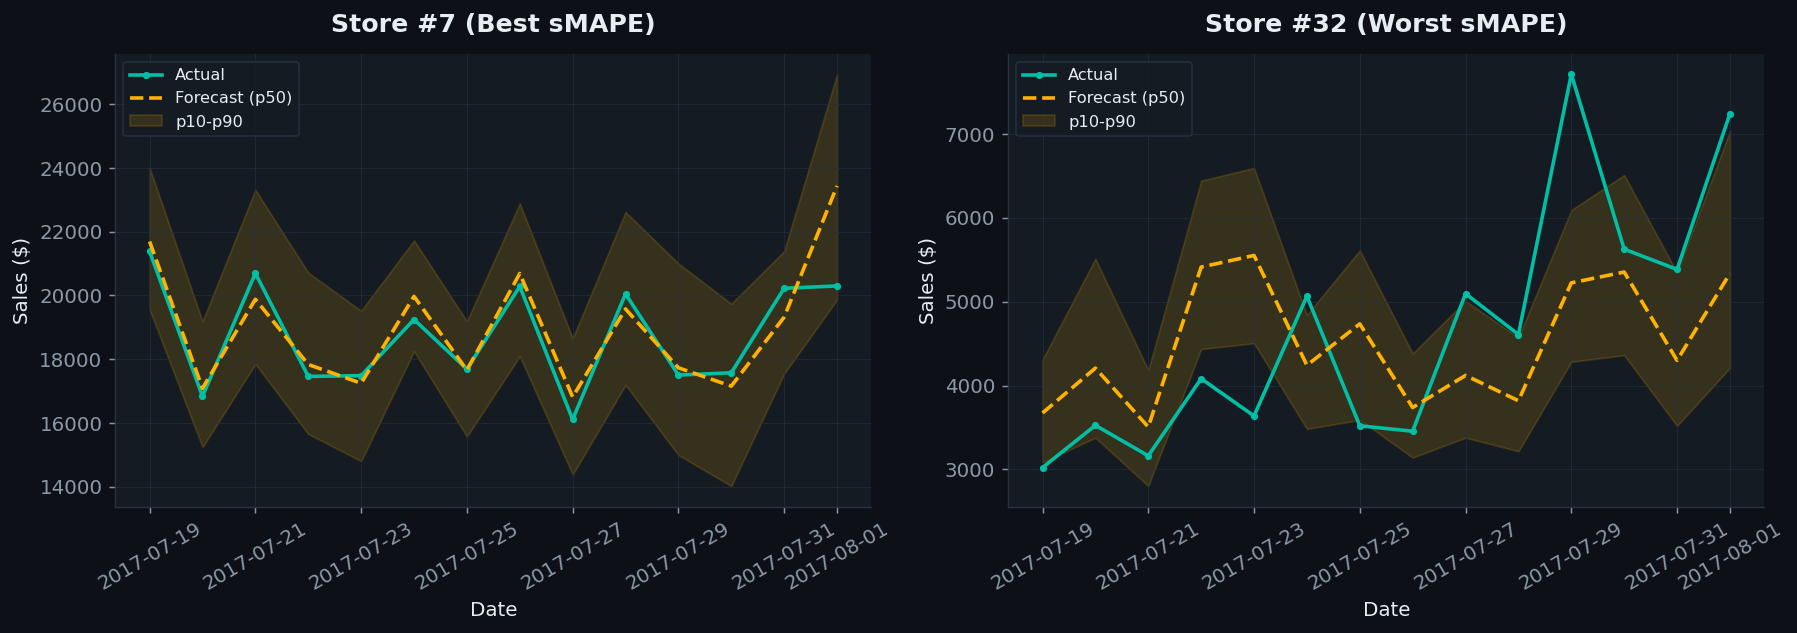

In [16]:
best_store = metrics_df["sMAPE"].idxmin()
worst_store = metrics_df["sMAPE"].idxmax()
sample_stores = [best_store, worst_store]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, store_nbr, label in zip(axes, sample_stores, ["Best sMAPE", "Worst sMAPE"]):
    sub = forecasts_df[forecasts_df["store_nbr"] == store_nbr]
    ax.plot(sub["date"], sub["actual"], color=TEAL, linewidth=2, label="Actual", marker="o", markersize=3)
    ax.plot(sub["date"], sub["p50"], color=AMBER, linewidth=2, linestyle="--", label="Forecast (p50)")
    ax.fill_between(sub["date"], sub["p10"], sub["p90"], color=AMBER, alpha=0.15, label="p10-p90")
    style_axes(ax, title=f"Store #{store_nbr} ({label})", xlabel="Date", ylabel="Sales ($)")
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "08_backtest_best_worst.png")
plt.show()

# 9. Forecast the Next 14 Days

Using the full history (no held-out tail), generate a genuine forecast for
the next `prediction_length` days beyond the end of the dataset, for a
handful of representative stores.

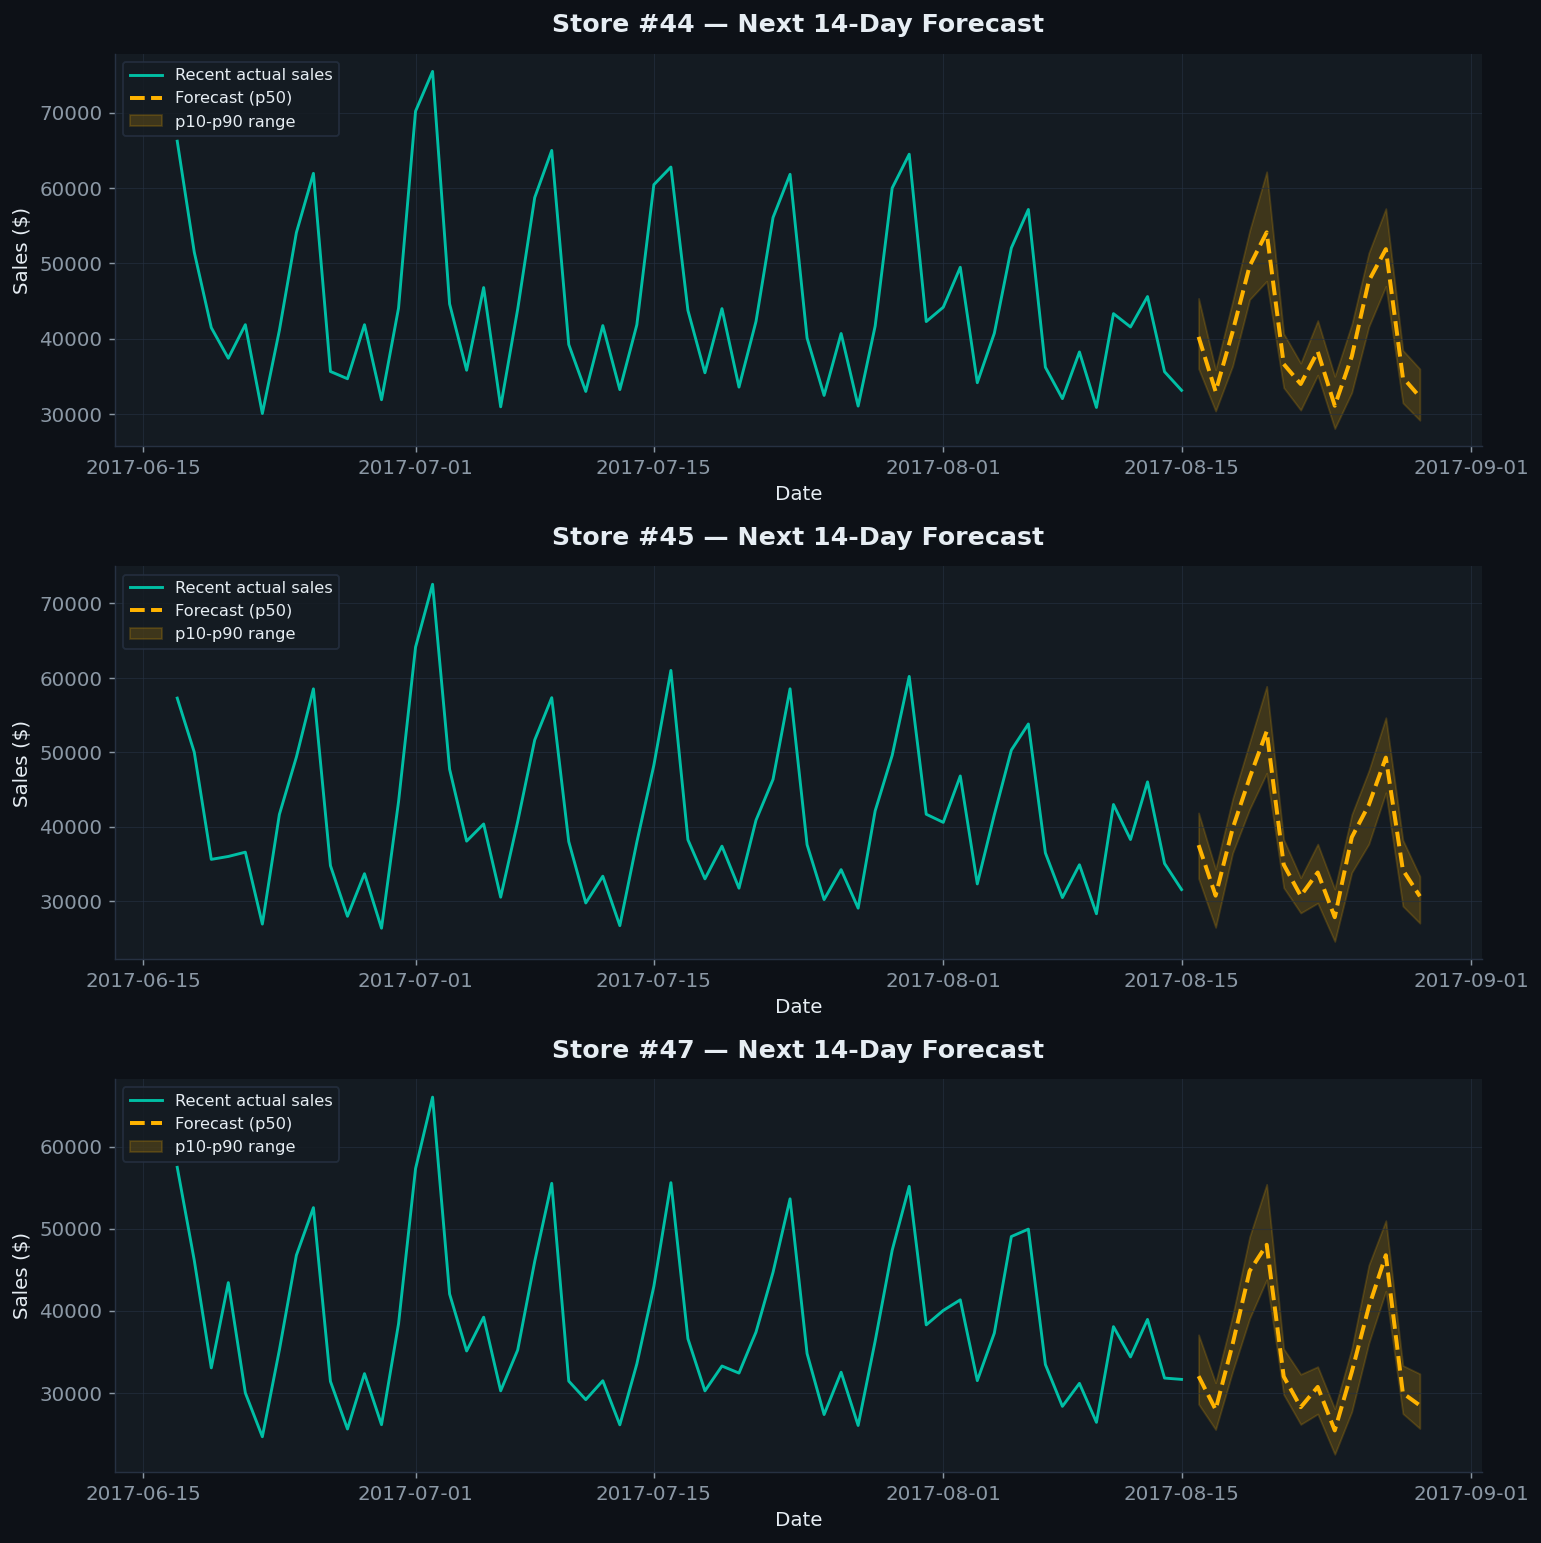

,store_nbr,date,mean,p10,p50,p90
0,44,2017-08-16,40534.839844,36024.281250,40246.371094,45359.300781
1,44,2017-08-17,32989.648438,30389.000000,32989.109375,35889.859375
2,44,2017-08-18,40868.820312,36368.839844,40936.738281,44956.421875
3,44,2017-08-19,49673.250000,45203.140625,49664.210938,54355.960938
4,44,2017-08-20,54715.531250,47643.261719,54128.800781,62177.281250
5,44,2017-08-21,36670.800781,33490.261719,36626.070312,40667.738281
6,44,2017-08-22,33885.210938,30515.160156,33980.601562,36755.519531
7,44,2017-08-23,38384.261719,35164.699219,38293.070312,42414.519531
8,44,2017-08-24,30923.660156,28063.050781,31098.720703,34999.218750
9,44,2017-08-25,37870.878906,32856.261719,37635.398438,41901.359375


In [17]:
showcase_stores = summary_tbl.index[:3].tolist()

fig, axes = plt.subplots(len(showcase_stores), 1, figsize=(12, 4 * len(showcase_stores)))
if len(showcase_stores) == 1:
    axes = [axes]

future_tables = []
for ax, store_nbr in zip(axes, showcase_stores):
    summary = forecast_for_store(panel, store_nbr, model=model, device=device)
    future_tables.append(summary)

    hist = panel[panel["store_nbr"] == store_nbr].sort_values("date").tail(60)
    ax.plot(hist["date"], hist["sales"], color=TEAL, linewidth=1.6, label="Recent actual sales")
    ax.plot(summary["date"], summary["p50"], color=AMBER, linewidth=2.2, linestyle="--", label="Forecast (p50)")
    ax.fill_between(summary["date"], summary["p10"], summary["p90"], color=AMBER, alpha=0.18, label="p10-p90 range")
    style_axes(ax, title=f"Store #{store_nbr} — Next 14-Day Forecast", xlabel="Date", ylabel="Sales ($)")
    ax.legend(fontsize=9, loc="upper left")

fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "09_future_forecasts.png")
plt.show()

future_df = pd.concat(future_tables, ignore_index=True)
future_df.to_csv(config.TABLES_DIR / "future_forecasts_showcase.csv", index=False)
future_df.round(2)

# 10. Save Model Artifacts

The trained weights, config and metadata are saved to `models/time_series_transformer/`
so the FastAPI backend (and any future notebook session) can reload the
model with `src.predict.load_model()` without retraining.

In [18]:
import json
print("Model directory:", config.MODEL_DIR)
print("Files:", [p.name for p in config.MODEL_DIR.glob("*")])
with open(config.METADATA_PATH) as f:
    print(json.dumps(json.load(f), indent=2))

Model directory: /media/junaid-ul-hassan/NewVolume/Personal-Projects/market-store-sales-time-series-forecasting/models/time_series_transformer
Files: ['config.json', 'metadata.json', 'model.safetensors']
{
  "num_stores": 54,
  "context_length": 60,
  "prediction_length": 14,
  "lags_sequence": [
    1,
    2,
    3,
    7,
    14,
    21,
    28
  ],
  "num_time_features": 5,
  "trained_rows": 91152,
  "last_date": "2017-08-15 00:00:00"
}


# 11. Conclusion

A compact HuggingFace `TimeSeriesTransformerForPrediction` model was trained
on 54 daily store-sales series and produces 14-day-ahead probabilistic
forecasts with uncertainty bands. All figures and tables above are saved
under `outputs/` and summarized in the project `README.md`. The saved model
in `models/time_series_transformer/` is served live by the FastAPI backend
(`api/main.py`) and visualized in the React dashboard (`frontend/`).